# Mood Article Recommender — Model A Training
## Logistic Regression on GoEmotions Dataset

This notebook trains a Logistic Regression classifier using Google's GoEmotions dataset (58k labeled sentences) mapped to our 25 mood labels. This gives the model real, diverse training data instead of relying on our small scraped article dataset.

**Pipeline:**
1. Load GoEmotions dataset (58k sentences, 27 emotion labels)
2. Map GoEmotions labels → our 25 moods
3. Generate sentence embeddings (all-MiniLM-L6-v2)
4. Train Logistic Regression classifier
5. Evaluate: accuracy, F1 score, confusion matrix
6. Save model files

In [1]:
# Cell 1 — Install dependencies
!pip install datasets sentence-transformers scikit-learn

In [2]:
# Cell 2 — Import libraries
import json
import numpy as np
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import joblib
from collections import Counter

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Cell 3 — Load GoEmotions dataset
print("Loading GoEmotions dataset (this may take a minute)...")
dataset = load_dataset("go_emotions", "simplified")
print("Dataset loaded!")
print(dataset)
print("\nTrain size:", len(dataset["train"]))

Loading GoEmotions dataset (this may take a minute)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

Dataset loaded!
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

Train size: 43410


In [4]:
# Cell 4 — Check GoEmotions labels
label_names = dataset["train"].features["labels"].feature.names
print("GoEmotions labels:", label_names)
print("\nTotal GoEmotions labels:", len(label_names))

GoEmotions labels: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']

Total GoEmotions labels: 28


In [5]:
# Cell 5 — Map GoEmotions labels → our 25 moods
EMOTION_TO_MOOD = {
    "anger":          "angry",
    "annoyance":      "angry",
    "disgust":        "angry",
    "joy":            "happy",
    "amusement":      "happy",
    "excitement":     "excited",
    "sadness":        "sad",
    "grief":          "sad",
    "disappointment": "disappointed",
    "fear":           "fearful",
    "nervousness":    "anxious",
    "confusion":      "confused",
    "surprise":       "confused",
    "boredom":        "bored",
    "tiredness":      "tired",
    "love":           "grateful",
    "gratitude":      "grateful",
    "admiration":     "inspired",
    "approval":       "proud",
    "pride":          "proud",
    "optimism":       "hopeful",
    "relief":         "calm",
    "caring":         "lonely",
    "curiosity":      "curious",
    "desire":         "motivated",
    "remorse":        "guilty",
    "embarrassment":  "guilty",
    "jealousy":       "jealous",
    "neutral":        "content",
    "realization":    "inspired",
}

print("Mood mapping defined!")
print("Mapped moods:", len(set(EMOTION_TO_MOOD.values())))
print("Unique moods:", sorted(set(EMOTION_TO_MOOD.values())))

Mood mapping defined!
Mapped moods: 21
Unique moods: ['angry', 'anxious', 'bored', 'calm', 'confused', 'content', 'curious', 'disappointed', 'excited', 'fearful', 'grateful', 'guilty', 'happy', 'hopeful', 'inspired', 'jealous', 'lonely', 'motivated', 'proud', 'sad', 'tired']


In [6]:
# Cell 6 — Build training data from GoEmotions
texts = []
labels = []

for sample in dataset["train"]:
    text = sample["text"]
    sample_labels = sample["labels"]

    for label_id in sample_labels:
        emotion = label_names[label_id]
        mood = EMOTION_TO_MOOD.get(emotion)
        if mood:
            texts.append(text)
            labels.append(mood)
            break  # one mood per sentence

print("Total training samples:", len(texts))
print("\nMood distribution:")
for mood, count in sorted(Counter(labels).items()):
    print(f"  {mood}: {count}")

Total training samples: 42008

Mood distribution:
  angry: 4292
  anxious: 106
  calm: 100
  confused: 2023
  content: 12927
  curious: 1772
  disappointed: 1028
  excited: 702
  fearful: 514
  grateful: 3654
  guilty: 660
  happy: 3261
  hopeful: 995
  inspired: 4855
  lonely: 966
  motivated: 543
  proud: 2654
  sad: 956


In [7]:
# Cell 7 — Generate sentence embeddings
# Note: This will take 3-5 minutes for ~40k-50k samples
print("Loading sentence transformer model...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

print("Generating embeddings... (this takes 3-5 minutes for ~50k samples)")
X = embedder.encode(texts, show_progress_bar=True, batch_size=128)
y = np.array(labels)

print("\nEmbeddings shape:", X.shape)
print("Done!")

Loading sentence transformer model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating embeddings... (this takes 3-5 minutes for ~50k samples)


Batches:   0%|          | 0/329 [00:00<?, ?it/s]


Embeddings shape: (42008, 384)
Done!


In [8]:
# Cell 8 — Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 33606
Testing samples: 8402


In [9]:
# Cell 9 — Train Logistic Regression
print("Training Logistic Regression model...")

model = LogisticRegression(
    max_iter=2000,
    random_state=42,
    C=5.0,
    solver="lbfgs",
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Training complete!")

Training Logistic Regression model...
Training complete!


In [10]:
# Cell 10 — Evaluate the model
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print("=" * 40)
print(f"Accuracy:  {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"F1 Score:  {f1:.4f}")
print("=" * 40)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy:  0.4843  (48.43%)
F1 Score:  0.4518

Detailed Classification Report:
              precision    recall  f1-score   support

       angry       0.48      0.42      0.45       858
     anxious       0.40      0.10      0.15        21
        calm       0.50      0.05      0.09        20
    confused       0.32      0.11      0.17       405
     content       0.49      0.79      0.60      2586
     curious       0.26      0.11      0.16       354
disappointed       0.40      0.14      0.21       206
     excited       0.45      0.24      0.32       140
     fearful       0.54      0.42      0.47       103
    grateful       0.62      0.59      0.61       731
      guilty       0.39      0.23      0.29       132
       happy       0.54      0.51      0.53       652
     hopeful       0.47      0.27      0.34       199
    inspired       0.49      0.44      0.46       971
      lonely       0.32      0.20      0.25       193
   motivated       0.45      0.28      0.34       109
  

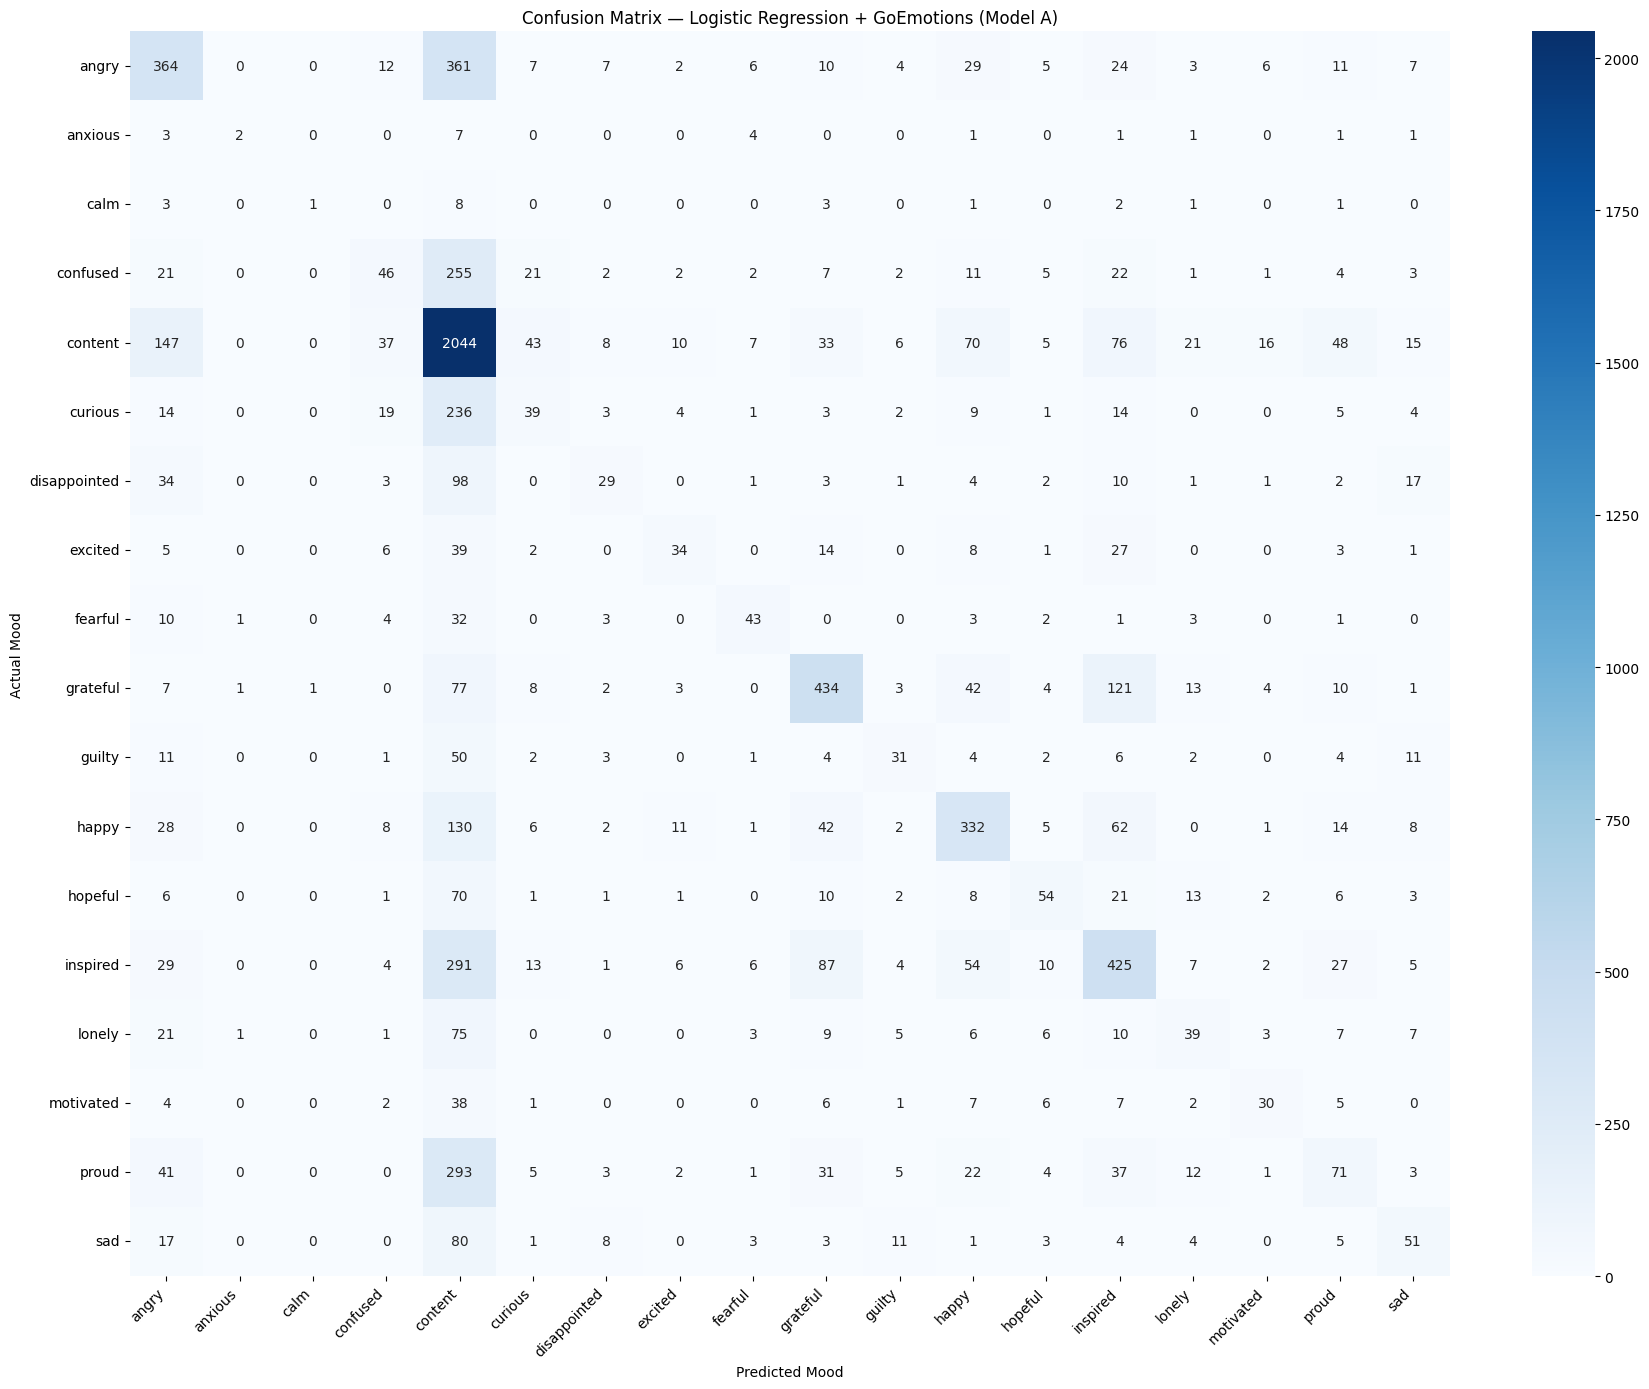

Saved confusion_matrix_lr.png


In [11]:
# Cell 11 — Confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(18, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_,
    cmap="Blues"
)
plt.title("Confusion Matrix — Logistic Regression + GoEmotions (Model A)")
plt.ylabel("Actual Mood")
plt.xlabel("Predicted Mood")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix_lr.png")
plt.show()
print("Saved confusion_matrix_lr.png")

In [12]:
# Cell 12 — Save model and config
joblib.dump(model, "model_lr.pkl")
print("Model saved as model_lr.pkl")

config = {
    "embedder": "all-MiniLM-L6-v2",
    "model_type": "logistic_regression",
    "moods": list(model.classes_),
    "num_moods": len(model.classes_),
    "trained_on": "GoEmotions (Google, 58k samples)"
}

with open("model_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Config saved as model_config.json")
print("\nModel classes:", list(model.classes_))

Model saved as model_lr.pkl
Config saved as model_config.json

Model classes: [np.str_('angry'), np.str_('anxious'), np.str_('calm'), np.str_('confused'), np.str_('content'), np.str_('curious'), np.str_('disappointed'), np.str_('excited'), np.str_('fearful'), np.str_('grateful'), np.str_('guilty'), np.str_('happy'), np.str_('hopeful'), np.str_('inspired'), np.str_('lonely'), np.str_('motivated'), np.str_('proud'), np.str_('sad')]


In [13]:
# Cell 13 — Download all output files
from google.colab import files
files.download("model_lr.pkl")
files.download("model_config.json")
files.download("confusion_matrix_lr.png")
print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
